# **Deep Learning Forecasting for USD/NGN Exchange Rate (TensorFlow / Keras)**

This notebook trains several deep learning architectures to forecast USD/NGN:
- MLP (feedforward)
- LSTM (recurrent)
- GRU (recurrent)
- 1D-CNN (temporal convolution)

Features & approach:
- Use the same lag and rolling features as earlier notebooks for tabular MLP models.
- For sequence models (LSTM/GRU/CNN), create sliding windows (lookback) of the raw rate or features.
- Use time-aware train/validation/test splits (no leakage).
- Hyperparameter tuning: try to use `keras_tuner` if installed; otherwise perform a manual grid search loop.
- Callbacks: EarlyStopping and ModelCheckpoint.
- Evaluation: MAE, RMSE, MAPE. Save predictions to CSV.

In [1]:
# import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import warnings
import random

2025-11-18 13:27:56.766673: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/apple/NGForexCast/.ngforecastenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
warnings.filterwarnings("ignore")
random.seed(12345)

In [3]:
# load features
df_feat = pd.read_csv('../../data/03_features/ngn_us_exchange_rates_features.csv')

# Display the feature engineered data
df_feat.head()

,Date,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
0,1997-04-11,84.66,-0.29,0.00,0.00,-0.040,0.000,0.08,1.24,-0.22,...,-3.685185,-inf,-0.879167,-1.973154,-6.800000,-0.768000,-1.58,4,11,1997
1,1997-05-02,85.05,0.25,0.00,0.00,0.108,0.560,0.00,0.06,0.30,...,-1.862069,-0.722222,2.125000,-7.250000,inf,-1.297619,inf,5,2,1997
2,1997-05-09,84.48,-0.32,0.25,0.00,0.000,0.900,0.00,0.00,0.08,...,-inf,-3.962963,-6.333333,-inf,0.454545,-1.780488,-1.80,5,9,1997
3,1997-05-16,84.48,0.02,-0.32,0.25,0.000,0.108,-0.04,0.00,0.06,...,inf,inf,inf,-1.909091,-0.600000,-0.900000,-0.96,5,16,1997
4,1997-05-23,84.96,0.41,0.02,-0.32,-0.290,0.000,0.56,0.00,0.00,...,0.640000,inf,inf,-2.863636,-1.745455,inf,inf,5,23,1997


In [4]:
# Convert transaction_time column to date format
df_feat["Date"] = pd.to_datetime(df_feat["Date"], errors="coerce")
df_feat.set_index("Date", inplace=True)

In [5]:
# Replace infinities with NaN, inspect and clean
df_feat.replace([np.inf, -np.inf], 0, inplace=True)

In [6]:
# Train-test split (time split)
test_size = int(len(df_feat)*0.012)
train = df_feat.iloc[:-test_size].copy()
test = df_feat.iloc[-test_size:].copy()

print("Train range:", train.index.min().date(), "to", train.index.max().date())
print("Test range:", test.index.min().date(), "to", test.index.max().date())

Train range: 1997-04-11 to 2025-07-18
Test range: 2025-07-25 to 2025-10-17


In [7]:
# Summary statistics
df_feat.describe()

,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,lag_16,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
count,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,...,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000
mean,279.682016,-0.230045,-0.127287,-0.086624,-0.382568,-0.468742,-0.420691,-0.338026,-0.009632,-0.501462,...,-5.125664,0.183616,3.718248,-9.319961,2.964863,4.769597,-5.647065,6.602094,15.602967,2010.252182
std,356.856576,12.945168,12.844267,12.625612,9.605964,9.357957,8.999670,8.404755,11.797981,8.658302,...,111.981286,54.819408,110.525783,292.294192,72.000368,342.766880,121.988299,3.436073,8.782195,8.113610
min,74.425000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,...,-3451.000000,-746.000000,-832.500000,-9524.000000,-626.000000,-5242.000000,-2155.000000,1.000000,1.000000,1997.000000
25%,126.175000,-0.300000,-0.200000,-0.200000,-0.190000,-0.190000,-0.150000,-0.157500,-0.150000,-0.200000,...,-1.619363,-1.600000,-1.431383,-1.499138,-1.380962,-1.329365,-1.384615,4.000000,8.000000,2003.000000
50%,151.355000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.730303,-0.721111,-0.654859,-0.640896,-0.666080,-0.733333,-0.674603,7.000000,16.000000,2010.000000
75%,304.200000,0.300000,0.207500,0.207500,0.210000,0.200000,0.200000,0.200000,0.200000,0.180000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,23.000000,2016.000000
max,1681.390000,287.900000,287.900000,287.900000,95.230000,95.230000,95.230000,95.230000,287.900000,95.230000,...,374.000000,1430.000000,2909.600000,1049.000000,1525.000000,9616.000000,871.424242,12.000000,31.000000,2025.000000


In [8]:
# Show feature columns
df_feat.columns

Index(['Rate', 'diff', 'lag_1', 'lag_2', 'lag_6', 'lag_8', 'lag_11', 'lag_13',
       'lag_15', 'lag_16', 'lag_25', 'lag_32', 'lag_34', 'rmean_4', 'rstd_4',
       'rmean_8', 'rstd_8', 'rmean_12', 'rstd_12', 'ret_3', 'ret_7', 'ret_14',
       'ret_21', 'ret_30', 'ret_60', 'ret_90', 'month', 'day', 'year'],
      dtype='object')

In [9]:
# Get feature columns and target variable
feature_cols = [c for c in df_feat.columns if c not in ["Rate"]]
X_train, y_train = train[feature_cols], train["Rate"]
X_test, y_test = test[feature_cols], test["Rate"]

In [10]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Sequence dataset creation (for LSTM/GRU/CNN)
def make_sequences(series, lookback=30, horizon=1, features=None, scaler=None):
    if features is not None:
        arr = features.values
    else:
        arr = series.values.reshape(-1,1)
    if scaler is not None:
        arr = scaler.transform(arr) if hasattr(scaler, "transform") else arr
    X, y = [], []
    for i in range(lookback, len(arr)-horizon+1):
        X.append(arr[i-lookback:i])
        y.append(series.values[i+horizon-1])
    return np.array(X), np.array(y)

lookback = 36
horizon = 1
series = df_feat["Rate"].reset_index(drop=True)
X_seq, y_seq = make_sequences(series, lookback=lookback, horizon=horizon, features=None, scaler=None)

In [12]:
# find split index in sequence space to match test_size
split_idx = len(df_feat) - test_size - lookback - (horizon-1)
if split_idx <= 0:
    raise ValueError("Not enough data for the chosen lookback/test_size. Reduce lookback or test_size.")
X_train_seq = X_seq[:split_idx]
y_train_seq = y_seq[:split_idx]
X_test_seq = X_seq[split_idx:]
y_test_seq = y_seq[split_idx:]
print("Sequence training samples:", X_train_seq.shape[0], "timesteps:", X_train_seq.shape[1], "features:", X_train_seq.shape[2])

Sequence training samples: 1097 timesteps: 36 features: 1


In [13]:
# Model builders
def build_mlp(input_shape, units=[64,32], lr=1e-3, dropout=0.1):
    inp = layers.Input(shape=(input_shape,))
    x = inp
    for u in units:
        x = layers.Dense(u, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

def build_lstm(input_shape, units=64, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(units, activation="tanh")(inp)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

def build_gru(input_shape, units=64, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.GRU(units, activation="tanh")(inp)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

def build_cnn1d(input_shape, filters=32, kernel_size=3, pool_size=2, dense_units=32, lr=1e-3, dropout=0.2):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(filters, kernel_size, activation="relu", padding="causal")(inp)
    x = layers.MaxPooling1D(pool_size)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

In [14]:
# Training & hyperparameter 

es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
model_dir = "dl_models"
os.makedirs(model_dir, exist_ok=True)
results = []

# --- MLP on tabular features ---
mlp_params_grid = [
    {"units":[64,32], "lr":1e-3, "dropout":0.1, "batch_size":32, "epochs":50},
    {"units":[128,64], "lr":5e-4, "dropout":0.2, "batch_size":64, "epochs":60},
]
for cfg in mlp_params_grid:
    print("Training MLP with", cfg)
    model = build_mlp(input_shape=X_train_scaled.shape[1], units=cfg["units"], lr=cfg["lr"], dropout=cfg["dropout"])
    history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=cfg["epochs"],
                        batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    y_pred = model.predict(X_test_scaled).flatten()
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    print(f"MLP MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
    results.append(("MLP", cfg, mae, rmse, mape))
    model.save(os.path.join(model_dir, f"mlp_{cfg['units']}.keras"))

# --- LSTM (univariate sequence) ---
lstm_params = [
    {"units":64, "lr":1e-3, "dropout":0.2, "batch_size":32, "epochs":60},
    {"units":128, "lr":5e-4, "dropout":0.2, "batch_size":64, "epochs":80},
]
for cfg in lstm_params:
    print("Training LSTM with", cfg)
    model = build_lstm(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), units=cfg["units"], dropout=cfg["dropout"], lr=cfg["lr"])
    history = model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=cfg["epochs"],
                        batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    y_pred = model.predict(X_test_seq).flatten()
    mae = mean_absolute_error(y_test_seq, y_pred)
    rmse = mean_squared_error(y_test_seq, y_pred)
    mape = np.mean(np.abs((y_test_seq - y_pred) / y_test_seq)) * 100
    print(f"LSTM MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
    results.append(("LSTM", cfg, mae, rmse, mape))
    model.save(os.path.join(model_dir, f"lstm_{cfg['units']}.keras"))

# --- GRU ---
gru_params = [
    {"units":64, "lr":1e-3, "dropout":0.2, "batch_size":32, "epochs":60},
]
for cfg in gru_params:
    print("Training GRU with", cfg)
    model = build_gru(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), units=cfg["units"], dropout=cfg["dropout"], lr=cfg["lr"])
    history = model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=cfg["epochs"],
                        batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    y_pred = model.predict(X_test_seq).flatten()
    mae = mean_absolute_error(y_test_seq, y_pred)
    rmse = mean_squared_error(y_test_seq, y_pred)
    mape = np.mean(np.abs((y_test_seq - y_pred) / y_test_seq)) * 100
    print(f"GRU MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
    results.append(("GRU", cfg, mae, rmse, mape))
    model.save(os.path.join(model_dir, f"gru_{cfg['units']}.keras"))

# --- 1D-CNN ---
cnn_params = [
    {"filters":32, "kernel_size":3, "pool_size":2, "dense_units":32, "lr":1e-3, "dropout":0.2, "batch_size":32, "epochs":60},
]
for cfg in cnn_params:
    print("Training CNN1D with", cfg)
    model = build_cnn1d(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
                        filters=cfg["filters"], kernel_size=cfg["kernel_size"],
                        pool_size=cfg["pool_size"], dense_units=cfg["dense_units"],
                        lr=cfg["lr"], dropout=cfg["dropout"])
    history = model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=cfg["epochs"],
                        batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    y_pred = model.predict(X_test_seq).flatten()
    mae = mean_absolute_error(y_test_seq, y_pred)
    rmse = mean_squared_error(y_test_seq, y_pred)
    mape = np.mean(np.abs((y_test_seq - y_pred) / y_test_seq)) * 100
    print(f"CNN1D MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
    results.append(("CNN1D", cfg, mae, rmse, mape))
    model.save(os.path.join(model_dir, f"cnn1d_{cfg['filters']}.keras"))


Training MLP with {'units': [64, 32], 'lr': 0.001, 'dropout': 0.1, 'batch_size': 32, 'epochs': 50}
1/1 [==============================] - 0s 110ms/step
MLP MAE: 1070.6609, RMSE: 1147037.3684, MAPE: 70.97%
Training MLP with {'units': [128, 64], 'lr': 0.0005, 'dropout': 0.2, 'batch_size': 64, 'epochs': 60}
1/1 [==============================] - 0s 133ms/step
MLP MAE: 1125.6327, RMSE: 1267997.6660, MAPE: 74.63%
Training LSTM with {'units': 64, 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32, 'epochs': 60}


2025-11-18 13:28:17.286644: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:28:17.291102: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:28:17.292867: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 431ms/step


2025-11-18 13:28:47.277936: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:28:47.279957: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:28:47.281691: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

LSTM MAE: 1411.9036, RMSE: 1994244.7361, MAPE: 93.60%
Training LSTM with {'units': 128, 'lr': 0.0005, 'dropout': 0.2, 'batch_size': 64, 'epochs': 80}


...

1/1 [==============================] - 1s 668ms/step
LSTM MAE: 1450.7995, RMSE: 2105598.2412, MAPE: 96.18%
Training GRU with {'units': 64, 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32, 'epochs': 60}


2025-11-18 13:29:39.090023: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:29:39.092600: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:29:39.094690: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 425ms/step


2025-11-18 13:30:07.224213: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:30:07.225912: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:30:07.227976: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

GRU MAE: 1409.5457, RMSE: 1987591.3671, MAPE: 93.44%
Training CNN1D with {'filters': 32, 'kernel_size': 3, 'pool_size': 2, 'dense_units': 32, 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32, 'epochs': 60}
1/1 [==============================] - 0s 80ms/step
CNN1D MAE: 84.4904, RMSE: 7660.6952, MAPE: 5.63%


In [15]:
# ---------------------------
# 6. Results table & plots
# ---------------------------
result_df = pd.DataFrame([{"model": r[0], "config": r[1], "MAE": r[2], "RMSE": r[3], "MAPE": r[4]} for r in results])
display(result_df.sort_values("MAE"))

,model,config,MAE,RMSE,MAPE
5,CNN1D,"{'filters': 32, 'kernel_size': 3, 'pool_size':...",84.490365,7.660695e+03,5.629477
0,MLP,"{'units': [64, 32], 'lr': 0.001, 'dropout': 0....",1070.660870,1.147037e+06,70.974172
1,MLP,"{'units': [128, 64], 'lr': 0.0005, 'dropout': ...",1125.632738,1.267998e+06,74.627922
4,GRU,"{'units': 64, 'lr': 0.001, 'dropout': 0.2, 'ba...",1409.545748,1.987591e+06,93.440977
2,LSTM,"{'units': 64, 'lr': 0.001, 'dropout': 0.2, 'ba...",1411.903557,1.994245e+06,93.597316
3,LSTM,"{'units': 128, 'lr': 0.0005, 'dropout': 0.2, '...",1450.799459,2.105598e+06,96.176596


In [16]:
# # Save forecasts 
# out = test[["date","rate"]].copy()
# for model_file in os.listdir(model_dir):
#     if model_file.endswith(".keras"):
#         try:
#             mdl = tf.keras.models.load_model(os.path.join(model_dir, model_file))
#             if "mlp" in model_file:
#                 preds = mdl.predict(X_test_scaled).flatten()
#                 out[model_file.replace(".keras","")] = preds
#             else:
#                 preds = mdl.predict(X_test_seq).flatten()
#                 seq_dates = df_feat.reset_index().index[lookback+split_idx:lookback+split_idx+len(preds)]
#                 seq_dates = pd.to_datetime(df.reset_index().iloc[lookback+split_idx:lookback+split_idx+len(preds)]["index"])
#                 out_seq = pd.DataFrame({"date": seq_dates.values, model_file.replace(".keras",""): preds})
#                 out = out.merge(out_seq, on="date", how="left")
#         except Exception as e:
#             print("Could not load model", model_file, e)

In [17]:
from tensorflow.keras.models import load_model

In [18]:
best_models = {}
for model_name in result_df["model"].unique():
    # Get the row with the lowest MAPE for this model
    best_row = result_df.loc[result_df[result_df["model"] == model_name]["MAPE"].idxmin()]
    best_cfg = best_row["config"]

    # infer filename pattern
    if model_name.lower() == "mlp":
        filename = f"mlp_{best_cfg['units']}.keras"
    elif model_name.lower() == "lstm":
        filename = f"lstm_{best_cfg['units']}.keras"
    elif model_name.lower() == "gru":
        filename = f"gru_{best_cfg['units']}.keras"
    elif model_name.lower() in ["cnn1d", "cnn"]:
        filename = f"cnn1d_{best_cfg['filters']}.keras"

    best_models[model_name] = load_model(os.path.join(model_dir, filename))

best_mlp = best_models.get("MLP")
best_lstm = best_models.get("LSTM")
best_gru  = best_models.get("GRU")
best_cnn  = best_models.get("CNN1D") or best_models.get("CNN")


2025-11-18 13:30:10.294267: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:30:10.296552: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:30:10.298084: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [19]:
# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    R2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    print(f"{name} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | R2: {R2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": R2}


In [20]:
# # Generate predictions from best models
y_pred_mlp  = best_mlp.predict(X_test_scaled).flatten()
y_pred_lstm = best_lstm.predict(X_test_seq).flatten()
y_pred_gru  = best_gru.predict(X_test_seq).flatten()
y_pred_cnn  = best_cnn.predict(X_test_seq).flatten()

1/1 [==============================] - 0s 437ms/step


2025-11-18 13:30:11.185205: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:30:11.187087: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:30:11.189425: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 436ms/step


2025-11-18 13:30:11.681423: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-11-18 13:30:11.682927: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-11-18 13:30:11.684399: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 81ms/step


In [21]:
# Evaluate and compile results
results = []
results.append(evaluate_model("MLP", y_test, y_pred_mlp))
results.append(evaluate_model("LSTM", y_test_seq, y_pred_lstm))
results.append(evaluate_model("GRU", y_test_seq, y_pred_gru))
results.append(evaluate_model("CNN1D", y_test_seq, y_pred_cnn))    

# Results Summary
results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

MLP | MAE: 1070.6609 | RMSE: 1147037.3684 | MAPE: 70.97% | R2: -1484.7814
LSTM | MAE: 1411.9036 | RMSE: 1994244.7361 | MAPE: 93.60% | R2: -2582.1868
GRU | MAE: 1409.5457 | RMSE: 1987591.3671 | MAPE: 93.44% | R2: -2573.5685
CNN1D | MAE: 84.4904 | RMSE: 7660.6952 | MAPE: 5.63% | R2: -8.9231


,Model,MAE,RMSE,MAPE,R2
3,CNN1D,84.490365,7.660695e+03,5.629477,-8.923058
0,MLP,1070.660870,1.147037e+06,70.974172,-1484.781406
2,GRU,1409.545748,1.987591e+06,93.440977,-2573.568517
1,LSTM,1411.903557,1.994245e+06,93.597316,-2582.186764


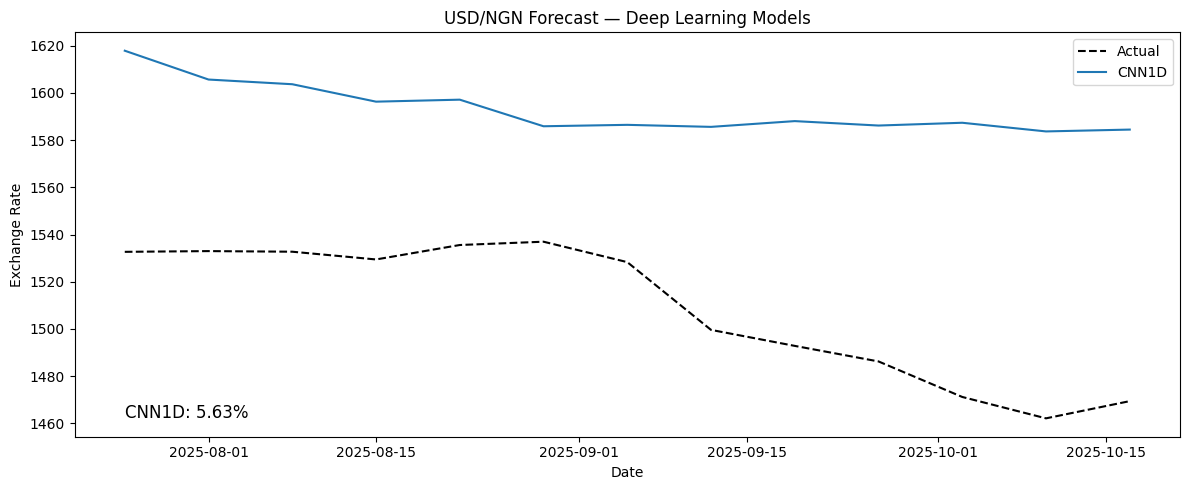

In [22]:
plt.figure(figsize=(12,5))
plt.plot(test.index, y_test_seq, label="Actual", color="black", linestyle="--")
cnn1D_mape = results_df[results_df['Model']=='CNN1D']['MAPE'].values[0]
# plt.plot(test.index, y_pred_mlp, label="MLP")
# plt.plot(test.index, y_pred_lstm, label="LSTM")
# plt.plot(test.index, y_pred_gru, label="GRU")
plt.plot(test.index, y_pred_cnn, label="CNN1D")
plt.text(test.index[0], min(y_test_seq), f"CNN1D: {cnn1D_mape:.2f}%", fontsize=12, color="black")
plt.legend()
plt.title("USD/NGN Forecast — Deep Learning Models")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.tight_layout()
plt.show()